# Predict Students' Dropout and Academic Success

In [2]:
# ===== Load the dataset =====
# Fetch the "Predict Students' Dropout and Academic Success" dataset from the UCI ML repository
import pandas as pd

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features  # feature columns
y = predict_students_dropout_and_academic_success.data.targets   # target column (dropout/enrolled/graduate)
  

In [3]:
# ===== Preview the features dataframe =====
X  # display the raw features dataframe

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [4]:
# ===== Inspect dataframe structure =====
X.info()  # show column dtypes, non-null counts, and memory usage

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [5]:
# ===== Check for duplicate rows =====
X.duplicated().sum()  # count how many rows are exact duplicates

np.int64(0)

In [6]:
# ===== Combine features and target into one dataframe =====
df = pd.concat([X,y],axis=1)  # concatenate features (X) and target (y) column-wise

In [7]:
# ===== One-hot encode all categorical columns =====
df_new = pd.get_dummies(df)  # convert categorical columns into dummy/indicator variables

In [8]:
# ===== Preview the encoded dataframe =====
df_new  # display the one-hot encoded dataframe

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_Dropout,Target_Enrolled,Target_Graduate
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.000000,0,10.8,1.4,1.74,True,False,False
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,13.666667,0,13.9,-0.3,0.79,False,False,True
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.000000,0,10.8,1.4,1.74,True,False,False
3,1,17,2,9773,1,1,122.0,1,38,37,...,10,5,12.400000,0,9.4,-0.8,-3.12,False,False,True
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,13.000000,0,13.9,-0.3,0.79,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,8,5,12.666667,0,15.5,2.8,-4.06,False,False,True
4420,1,1,2,9773,1,1,120.0,105,1,1,...,6,2,11.000000,0,11.1,0.6,2.02,True,False,False
4421,1,1,1,9500,1,1,154.0,1,37,37,...,9,1,13.500000,0,13.9,-0.3,0.79,True,False,False
4422,1,1,1,9147,1,1,180.0,1,37,37,...,6,5,12.000000,0,9.4,-0.8,-3.12,False,False,True


In [9]:
# ===== Build a reduced dataframe: curricular-unit stats + unemployment rate + target =====
df_new = df[['Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)', 
   'Curricular units 1st sem (evaluations)',          
  'Curricular units 1st sem (approved)',            
  'Curricular units 1st sem (grade)',               
   'Curricular units 1st sem (without evaluations)' ,  
   'Curricular units 2nd sem (credited)' ,             
   'Curricular units 2nd sem (enrolled)' ,            
   'Curricular units 2nd sem (evaluations)' ,        
   'Curricular units 2nd sem (approved)'    ,         
   'Curricular units 2nd sem (grade)',               
   'Curricular units 2nd sem (without evaluations)',   
   'Unemployment rate' ,'Target'] ]  # subset to curricular-unit columns, unemployment rate, and target

df_new = pd.get_dummies(df_new)  # one-hot encode this subset (mainly expands the categorical 'Target' column)

<Axes: >

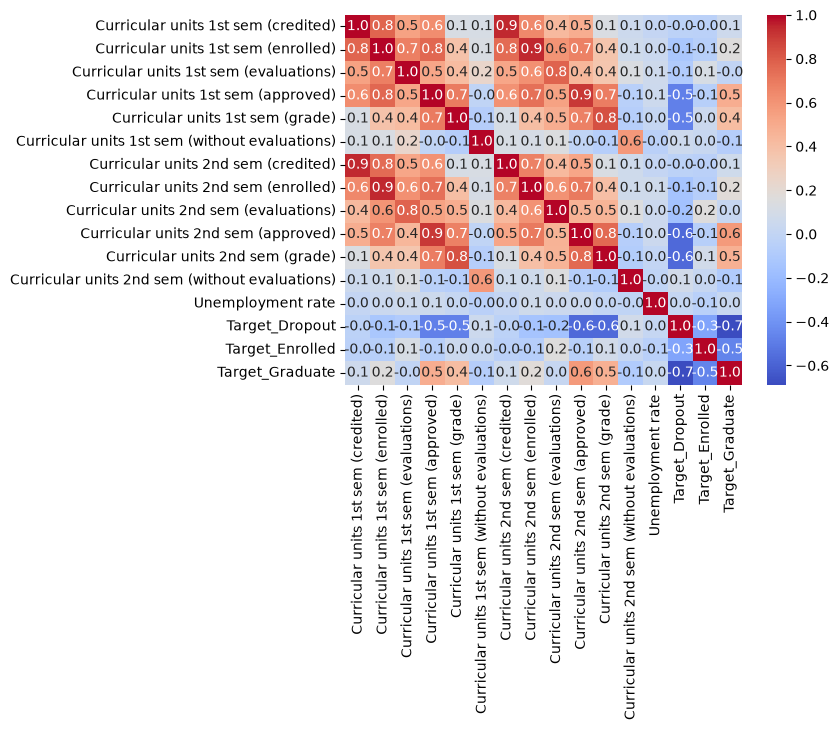

In [10]:
# ===== Visualize correlations between the selected features =====
import seaborn as sns

sns.heatmap(df_new.corr(),annot=True,fmt=".1f",   # correlation matrix, values annotated to 1 decimal place
    cmap="coolwarm")   # diverging colormap: red = positive correlation, blue = negative correlation

In [43]:
# ===== Prepare final feature matrix and binary target =====
X = df.drop(columns=['Target'])  # drop the target column to get features only

y = df["Target"].map({           # collapse the 3-class target into a binary "will dropout" flag
    "Dropout": 1,
    "Graduate": 0,
    "Enrolled": 0
})

In [44]:
# ===== Preview the final features dataframe =====
X

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [45]:
# ===== Preview the final binary target =====
y

0       1
1       0
2       1
3       0
4       0
       ..
4419    0
4420    1
4421    1
4422    0
4423    0
Name: Target, Length: 4424, dtype: int64

In [46]:
# ===== Split data into train and test sets =====
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # hold out 20% of the data for testing
    random_state=42,     # fixed seed for reproducibility
    stratify=y           # preserve the dropout/non-dropout class ratio in both splits
)

In [47]:
# ===== Sanity check: train features and labels have matching length =====
len(X_train) == len(y_train)

True

In [48]:
# ===== Sanity check: test features and labels have matching length =====
len(X_test) == len(y_test)

True

In [49]:
# ===== Preprocess data and train a baseline Logistic Regression model =====
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Find categorical and numerical columns
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),   # one-hot encode categoricals; ignore unseen categories at inference time
         categorical_columns),

        ("num", StandardScaler(),                          # standardize numeric columns to zero mean / unit variance
         numerical_columns)
    ]
)

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)  # fit the preprocessor on train data, then transform it
X_test_encoded = preprocessor.transform(X_test)         # apply the already-fitted transform to test data (no re-fitting)

# Logistic Regression
model = LogisticRegression(max_iter=2000,class_weight="balanced")  # class_weight balances the minority dropout class

model.fit(X_train_encoded, y_train)  # train the logistic regression model

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [50]:
# ===== Generate predictions on the training set =====
y_pred_train = model.predict(X_train_encoded)

print(y_pred_train)

[1 0 1 ... 1 1 1]


In [51]:
# ===== Generate predictions on the test set =====
y_pred = model.predict(X_test_encoded)

print(y_pred)

[0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0
 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 1
 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0
 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0
 0 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0
 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1 1 1
 0 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 0 1 1 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0
 0 0 0 0 0 0 1 0 0 0 0 0 

Train Accuracy: 0.8691720825091834

Train Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2402
           1       0.78      0.82      0.80      1137

    accuracy                           0.87      3539
   macro avg       0.85      0.86      0.85      3539
weighted avg       0.87      0.87      0.87      3539

[[2145  257]
 [ 206  931]]


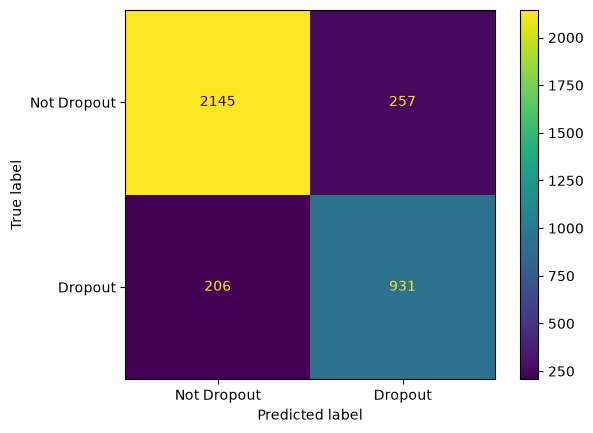

Test Accuracy: 0.8734463276836159

Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       601
           1       0.79      0.83      0.81       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.86       885
weighted avg       0.88      0.87      0.87       885


Test Confusion Matrix:
[[537  64]
 [ 48 236]]


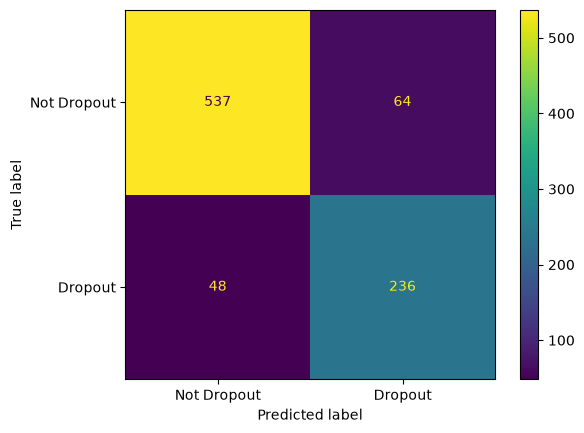

In [52]:
# ===== Evaluate model performance on train and test sets =====
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))  # overall accuracy on train data

print("\nTrain Classification Report:")
print(classification_report(y_train, y_pred_train))  # precision/recall/F1 per class on train data

cm = confusion_matrix(y_train, y_pred_train)  # train confusion matrix

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Dropout", "Dropout"]   # human-readable class labels
)


disp.plot()   # render the train confusion matrix

plt.show()

print("Test Accuracy:", accuracy_score(y_test, y_pred))  # overall accuracy on test data

print("\nTest Classification Report:")

print(classification_report(y_test, y_pred))  # precision/recall/F1 per class on test data

print("\nTest Confusion Matrix:")

cm = confusion_matrix(y_test, y_pred)  # test confusion matrix

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Dropout", "Dropout"]
)

disp.plot()   # render the test confusion matrix
plt.show()

In [21]:
# ===== Check class balance of the target variable =====
df['Target'].value_counts()  # count of Dropout / Graduate / Enrolled rows

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [22]:
# ===== Inspect dropout cases the model failed to catch (false negatives) =====
y_prob = model.predict_proba(X_test_encoded)[:, 1]  # predicted probability of dropout (class 1)

missed = X_test.copy()  # copy test features so we can annotate without mutating X_test

missed["Actual"] = y_test               # true label
missed["Predicted"] = y_pred            # predicted label
missed["Dropout_Probability"] = y_prob  # predicted probability of dropout

missed_dropout = missed[
    (missed["Actual"] == 1) &      # actually dropped out
    (missed["Predicted"] == 0)     # but the model predicted "not dropout"
]

pd.DataFrame(missed_dropout)  # display the missed dropout cases

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Actual,Predicted,Dropout_Probability
2597,1,43,1,171,1,1,145.0,1,19,38,...,0,0,0.000000,0,13.9,-0.3,0.79,1,0,0.285852
3030,1,7,1,9853,1,3,130.0,1,37,37,...,22,11,11.909091,0,7.6,2.6,0.32,1,0,0.214459
251,1,1,3,9773,1,1,131.0,1,38,37,...,6,6,12.833333,0,8.9,1.4,3.51,1,0,0.080771
487,1,39,1,9670,1,1,120.0,1,1,19,...,14,4,11.750000,0,13.9,-0.3,0.79,1,0,0.384660
4027,1,1,6,9500,1,1,139.0,1,19,38,...,10,6,13.066667,0,12.7,3.7,-1.70,1,0,0.270971
2698,1,44,1,9070,1,39,123.9,1,37,1,...,10,8,12.750000,1,16.2,0.3,-0.92,1,0,0.378463
1648,1,1,5,9500,1,1,130.0,1,19,37,...,15,7,12.142857,0,15.5,2.8,-4.06,1,0,0.107750
2251,1,16,1,171,1,1,122.0,1,19,37,...,13,7,12.250000,0,12.4,0.5,1.79,1,0,0.407179
3485,2,39,1,9670,1,1,130.0,1,19,38,...,12,5,11.400000,0,13.9,-0.3,0.79,1,0,0.452761
486,1,43,2,9670,1,1,125.0,1,38,19,...,10,4,10.571429,0,10.8,1.4,1.74,1,0,0.485645


In [23]:
# ===== Re-predict using a lower probability threshold to catch more dropouts =====
y_prob = model.predict_proba(X_test_encoded)[:, 1]  # predicted probability of dropout

y_pred_new = (y_prob >= 0.40).astype(int)  # flag as dropout if probability >= 0.40 (instead of the default 0.5)

In [25]:
# ===== Evaluate performance with the adjusted 0.40 threshold =====
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[505  96]
 [ 38 246]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88       601
           1       0.72      0.87      0.79       284

    accuracy                           0.85       885
   macro avg       0.82      0.85      0.83       885
weighted avg       0.86      0.85      0.85       885



In [34]:
# ===== Train and evaluate a Random Forest classifier =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
     n_estimators=200,       # number of trees in the forest
    max_depth=8,             # limit tree depth to reduce overfitting
    min_samples_split=10,    # minimum samples required to split an internal node
    min_samples_leaf=5,      # minimum samples required at a leaf node
    random_state=42          # fixed seed for reproducibility
)

# Train
rf_model.fit(X_train, y_train)  # note: fits on raw (unencoded) X_train

# Train Predict 
y_pred_rf_train = rf_model.predict(X_train)

# Train Predict 
y_pred_rf_test = rf_model.predict(X_test)  # (this is actually the test-set prediction)


# Train Results
print("Random Forest Accuracy:", accuracy_score(y_train, y_pred_rf_train))

print("\nRandom Forest Classification Report:")
print(classification_report(y_train, y_pred_rf_train))

print("\nTrain Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_rf_train))



# Test Results
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_test))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf_test))

print("\nTrain Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_test))



Random Forest Accuracy: 0.9005368748233964

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2402
           1       0.93      0.75      0.83      1137

    accuracy                           0.90      3539
   macro avg       0.91      0.86      0.88      3539
weighted avg       0.90      0.90      0.90      3539


Train Confusion Matrix:
[[2335   67]
 [ 285  852]]
Random Forest Accuracy: 0.8768361581920904

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.91       601
           1       0.88      0.71      0.79       284

    accuracy                           0.88       885
   macro avg       0.88      0.83      0.85       885
weighted avg       0.88      0.88      0.87       885


Train Confusion Matrix:
[[574  27]
 [ 82 202]]


Feature Importance:
Curricular units 2nd sem (approved)               0.232903
Curricular units 2nd sem (grade)                  0.148219
Curricular units 1st sem (approved)               0.109679
Tuition fees up to date                           0.091676
Curricular units 1st sem (grade)                  0.083155
Age at enrollment                                 0.041751
Curricular units 2nd sem (evaluations)            0.030658
Curricular units 2nd sem (enrolled)               0.024827
Course                                            0.024724
Curricular units 1st sem (evaluations)            0.024709
Debtor                                            0.022846
Curricular units 1st sem (enrolled)               0.021970
Admission grade                                   0.016473
Previous qualification (grade)                    0.014190
Application mode                                  0.013464
Father's occupation                               0.011236
Scholarship holder                  

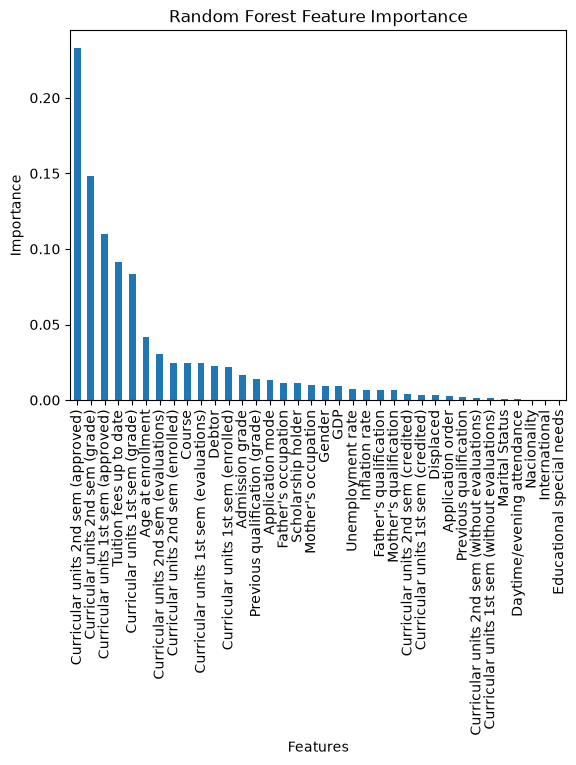

In [35]:
# ===== Plot Random Forest feature importances =====
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,   # importance score per feature
    index=X_train.columns             # align scores with feature names
)

importance = importance.sort_values(ascending=False)  # sort from most to least important

print("Feature Importance:")
print(importance)

importance.plot(kind="bar")  # bar chart of feature importances
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()



In [36]:
# ===== Hyperparameter tuning for Random Forest via GridSearchCV =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42   # fixed seed for reproducibility
)

param_grid = {                          # grid of hyperparameter combinations to search
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    scoring="f1",     # optimize for F1 score (better than accuracy for imbalanced classes)
    n_jobs=-1          # use all available CPU cores
)

grid_search.fit(X_train, y_train)  # run the grid search over the training data

print("Best Parameters:")
print(grid_search.best_params_)  # best hyperparameter combination found

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)   # best cross-validated F1 score

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation F1:
0.7770140207413971


In [55]:
# ===== Evaluate the best Random Forest model from grid search =====
best_rf = grid_search.best_estimator_  # extract the best-performing model

y_pred_train = best_rf.predict(X_train)

y_pred = best_rf.predict(X_test)


print("\nTrain Accuracy:")
print(accuracy_score(y_train, y_pred_train))

print("\nTrain Classification Report:")
print(classification_report(y_train, y_pred_train))

print("\nTrain Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train))

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Train Accuracy:
0.9101441085052274

Train Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2402
           1       0.95      0.76      0.85      1137

    accuracy                           0.91      3539
   macro avg       0.92      0.87      0.89      3539
weighted avg       0.91      0.91      0.91      3539


Train Confusion Matrix:
[[2352   50]
 [ 268  869]]

Test Accuracy:
0.8824858757062147

Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.89      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885


Test Confusion Matrix:
[[575  26]
 [ 78 206]]


In [64]:
# ===== Train a scaled Logistic Regression model and compute ROC-AUC =====
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)          # transform test with same scaler

model = LogisticRegression(max_iter=1000)          # bump max_iter too
model.fit(X_train_scaled, y_train)  # train logistic regression on scaled features

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])  # AUC on test set

print("Test AUC",auc)

auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])  # AUC on train set

print("Train AUC",auc)



Test AUC 0.9266070633451289
Train AUC 0.920847988739961


In [65]:
# ===== Compare classification metrics across several probability thresholds (logistic regression) =====
from sklearn.metrics import classification_report, confusion_matrix

for threshold in [0.5, 0.4, 0.3, 0.2]:   # try a handful of candidate thresholds

    y_pred_threshold = (y_prob_lr >= threshold).astype(int)  # classify as dropout if prob >= threshold

    print("\n==============================")
    print("Threshold:", threshold)
    print("==============================")

    print(classification_report(y_test, y_pred_threshold))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.84      0.96      0.89       601
           1       0.89      0.60      0.71       284

    accuracy                           0.85       885
   macro avg       0.86      0.78      0.80       885
weighted avg       0.85      0.85      0.84       885

Confusion Matrix:
[[579  22]
 [114 170]]

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       601
           1       0.81      0.67      0.73       284

    accuracy                           0.84       885
   macro avg       0.83      0.80      0.81       885
weighted avg       0.84      0.84      0.84       885

Confusion Matrix:
[[555  46]
 [ 93 191]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       601
           1       0.71      0.81      0.75       284

    accuracy                           0.83       88

In [73]:
# ===== Compare default 0.5-threshold predictions vs. explicit probability-based predictions =====
from sklearn.metrics import accuracy_score, classification_report

# Standard 0.5 prediction

y_pred_lr_train = lr_model.predict(X_train)  # default predict() applies a 0.5 threshold internally

y_pred_lr = lr_model.predict(X_test)

print("======== Train Report ========")

print("Accuracy:", accuracy_score(y_train, y_pred_lr_train))

print("\nClassification Report:")
print(classification_report(y_train, y_pred_lr_train))

print("\nProbability-based prediction:")
y_pred_prob = (y_pred_lr_train >= 0.5).astype(int)  # note: this thresholds the predicted labels, not probabilities

print("Same predictions:",
      (y_pred_lr_train == y_pred_prob).all())   # confirm both approaches agree
print("======== Test Report ========")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nProbability-based prediction:")
y_pred_prob = (y_prob_lr >= 0.5).astype(int)  # threshold the actual predicted probabilities at 0.5

print("Same predictions:",
      (y_pred_lr == y_pred_prob).all())   # confirm both approaches agree

======== Train Report ========
Accuracy: 0.836959593105397

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      2402
           1       0.86      0.59      0.70      1137

    accuracy                           0.84      3539
   macro avg       0.84      0.77      0.79      3539
weighted avg       0.84      0.84      0.83      3539


Probability-based prediction:
Same predictions: True
======== Test Report ========
Accuracy: 0.8463276836158192

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89       601
           1       0.89      0.60      0.71       284

    accuracy                           0.85       885
   macro avg       0.86      0.78      0.80       885
weighted avg       0.85      0.85      0.84       885


Probability-based prediction:
Same predictions: True


In [74]:
# ===== Sweep thresholds to find the one that maximizes F1 (logistic regression, test set) =====
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.10, 0.91, 0.01)  # candidate thresholds from 0.10 to 0.90 in steps of 0.01

results = []

for threshold in thresholds:
    y_pred = (y_prob_lr >= threshold).astype(int)  # classify as dropout if prob >= threshold

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)  # collect all threshold results into a dataframe

best_row = results_df.loc[results_df["f1"].idxmax()]  # pick the row with the highest F1 score

print("Best Threshold:", best_row["threshold"])
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("F1:", best_row["f1"])

Best Threshold: 0.34999999999999987
Precision: 0.7773722627737226
Recall: 0.75
F1: 0.7634408602150538


In [75]:
# ===== Define a reusable prediction function with a fixed threshold =====
def predict_churn(customer_data):

    probability = lr_model.predict_proba(customer_data)[:, 1]  # predicted dropout probability

    threshold = 0.35  # decision threshold chosen for this function

    prediction = (probability >= threshold).astype(int)  # binary prediction based on threshold

    return prediction, probability

In [76]:
# ===== Run the prediction function on the test set =====
prediction, probability = predict_churn(X_test)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1
 0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0
 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1
 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1
 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0
 0 0 0 1 0 0 

In [86]:
# ===== Build and train the final production pipeline (scaler + logistic regression) =====
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_model = Pipeline([
    ("scaler", StandardScaler()),                                     # standardize features
    ("logistic", LogisticRegression(max_iter=2000, random_state=42))  # logistic regression classifier
])

final_model.fit(X_train2, y_train2)  # train the full pipeline on the training split

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['Marital Status','Application mode','Application order',..., 'Unemployment rate','Inflation rate','GDP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [87]:
# ===== Preview predicted dropout probabilities on the validation set =====
val_prob = final_model.predict_proba(X_val)[:, 1]

print(val_prob[:10])  # show the first 10 predicted probabilities

[0.89724697 0.75072779 0.02890336 0.49211935 0.90035251 0.07800037
 0.21689828 0.07698315 0.93918005 0.33541355]


In [89]:
# ===== Sweep thresholds on the validation set to pick the best F1 threshold =====
val_prob = final_model.predict_proba(X_val)[:, 1]  # predicted dropout probabilities on validation set

thresholds = np.arange(0.10, 0.91, 0.01)  # candidate thresholds

results = []

for threshold in thresholds:

    val_pred = (val_prob >= threshold).astype(int)  # classify as dropout if prob >= threshold

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred)
    })

results_df = pd.DataFrame(results)

best = results_df.loc[results_df["f1"].idxmax()]  # threshold that maximizes F1 on validation set

print("Best Validation Threshold:", best["threshold"])
print("Validation Precision:", best["precision"])
print("Validation Recall:", best["recall"])
print("Validation F1:", best["f1"])

Best Validation Threshold: 0.4199999999999998
Validation Precision: 0.8122270742358079
Validation Recall: 0.8193832599118943
Validation F1: 0.8157894736842105


In [90]:
# ===== Final evaluation on the held-out test set using the validation-selected threshold =====
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# Test probabilities
test_prob = final_model.predict_proba(X_test)[:, 1]

# Use threshold selected from validation
best_threshold = best["threshold"]

test_pred = (test_prob >= best_threshold).astype(int)  # apply the chosen threshold to test probabilities

print("======== FINAL TEST RESULTS ========")

print("Threshold:", best_threshold)

print("\nAccuracy:")
print(accuracy_score(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, test_prob))  # AUC is computed on probabilities, not thresholded predictions

======== FINAL TEST RESULTS ========
Threshold: 0.4199999999999998

Accuracy:
0.8813559322033898

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.84      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885


Confusion Matrix:
[[560  41]
 [ 64 220]]

ROC-AUC:
0.9262321014271988


In [91]:
# ===== Persist the trained model and threshold to disk =====
import joblib

# Save the trained model
joblib.dump(final_model, "churn_model.pkl")  # serialize the pipeline (scaler + logistic regression)

# Save the threshold
joblib.dump(best_threshold, "churn_threshold.pkl")  # serialize the chosen decision threshold

print("Model saved successfully!")
print("Threshold:", best_threshold)

Model saved successfully!
Threshold: 0.4199999999999998


In [92]:
# ===== Reload the saved model and threshold to verify persistence works =====
model = joblib.load("churn_model.pkl")          # load the trained pipeline back from disk
threshold = joblib.load("churn_threshold.pkl")  # load the saved threshold back from disk

print("Model loaded!")
print("Threshold:", threshold)

Model loaded!
Threshold: 0.4199999999999998
